In [21]:
!pip3 install qiskit qiskit_aer matplotlib pylatexenc

Bell State Circuit: Use the H and CNOT gates to create an entangled pair. Show the histogram and explain why only 00 and 11 appear.

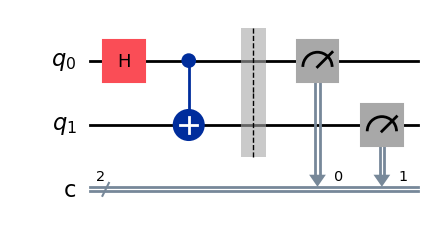

In [22]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(2, 2)
qc.h(0)          
qc.cx(0, 1)      
qc.barrier()
qc.measure([0, 1], [0, 1])

display(qc.draw('mpl'))

Only 00 and 11 appear in measurements. This occurs because the qubits are entangled; their states are correlated.

Measurement counts: {'00': 488, '11': 536}


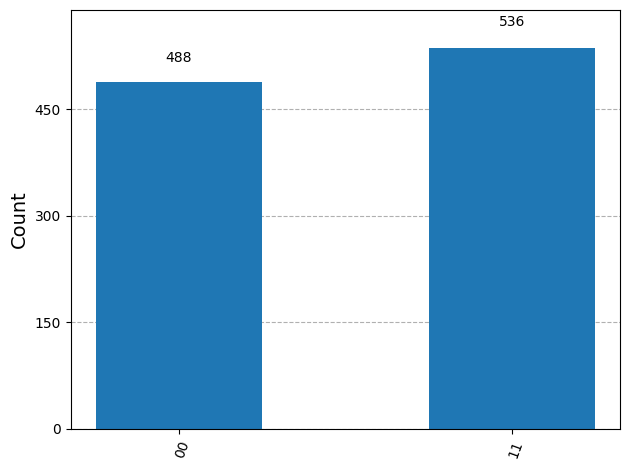

In [23]:
from qiskit_aer import AerSimulator
from qiskit import transpile

backend = AerSimulator()
tqc = transpile(qc, backend)   
job = backend.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

plot_histogram(counts)

Quantum Phase Kickback Algorithm: Demonstrate how a controlled-phase rotation transfers a phase to the control qubit. Include Bloch sphere and histogram visualizations.

Statevector([ 0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
              7.07106781e-01+0.j        , -2.59734824e-06+0.70710678j],
            dims=(2, 2))


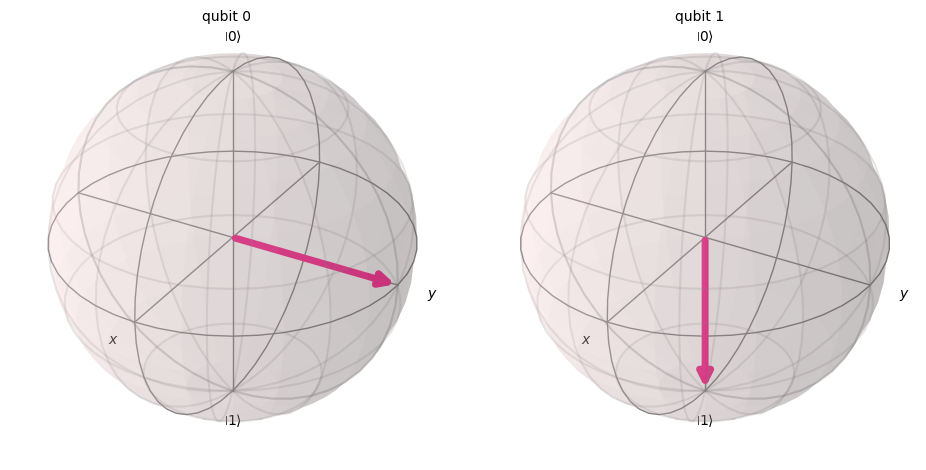

In [24]:
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector  

qc = QuantumCircuit(2)

qc.h(0)

qc.x(1)

theta = 1.5708  # π/2
qc.cp(theta, 0, 1)

print(Statevector(qc))
plot_bloch_multivector(qc)

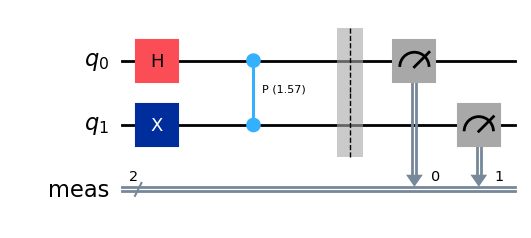

In [25]:
qc.measure_all()

sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
plot_histogram(counts)
plt.show()

qc.draw('mpl')

The histogram shows how the control qubit's state is affected by the phase kickback.

Measurement counts: {'10': 514, '11': 510}


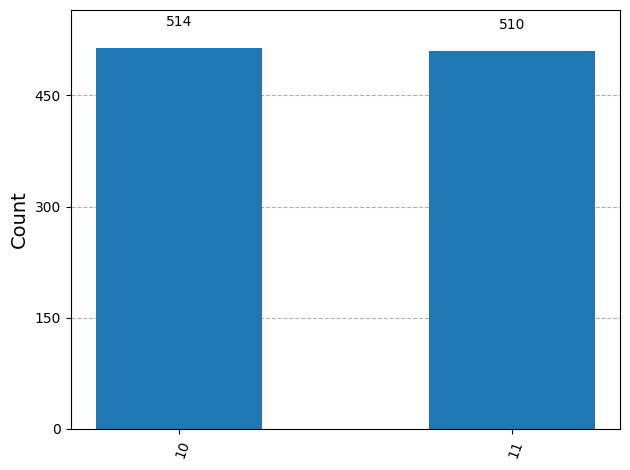

In [26]:
backend = AerSimulator()
tqc = transpile(qc, backend)   
job = backend.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

plot_histogram(counts)

Deutsch–Jozsa Algorithm: Implement both constant and balanced oracle functions to test how the algorithm distinguishes them in a single quantum query.

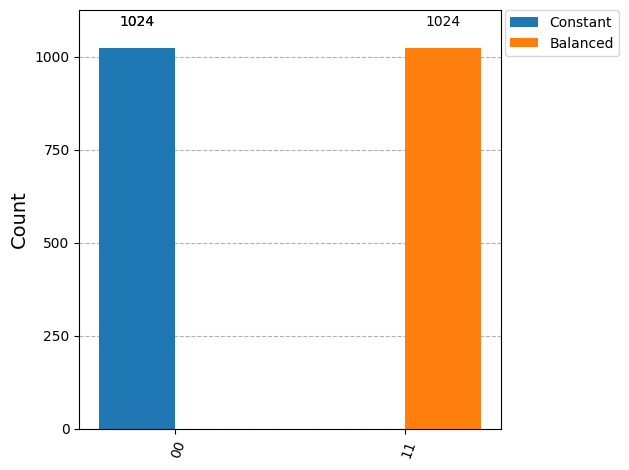

In [27]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

n = 2  


def constant_oracle(n_qubits):
    oracle = QuantumCircuit(n_qubits+1)
    return oracle

def balanced_oracle(n_qubits):
    oracle = QuantumCircuit(n_qubits+1)
    oracle.cx(0, n_qubits)
    oracle.cx(1, n_qubits)
    return oracle

def deutsch_jozsa_circuit(oracle, n_qubits):
    qc = QuantumCircuit(n_qubits+1, n_qubits)
    
    qc.x(n_qubits)
    qc.h(n_qubits)
    
    for q in range(n_qubits):
        qc.h(q)
    
    qc.append(oracle.to_gate(), range(n_qubits+1))
    
    for q in range(n_qubits):
        qc.h(q)
    
    for q in range(n_qubits):
        qc.measure(q, q)
    
    return qc

oracle_const = constant_oracle(n)
oracle_bal = balanced_oracle(n)

dj_const = deutsch_jozsa_circuit(oracle_const, n)
dj_bal = deutsch_jozsa_circuit(oracle_bal, n)


sim = AerSimulator()

compiled_const = transpile(dj_const, sim)
compiled_bal = transpile(dj_bal, sim)

result_const = sim.run(compiled_const, shots=1024).result()
result_bal = sim.run(compiled_bal, shots=1024).result()

counts_const = result_const.get_counts()
counts_bal = result_bal.get_counts()

plot_histogram([counts_const, counts_bal], legend=['Constant', 'Balanced'])


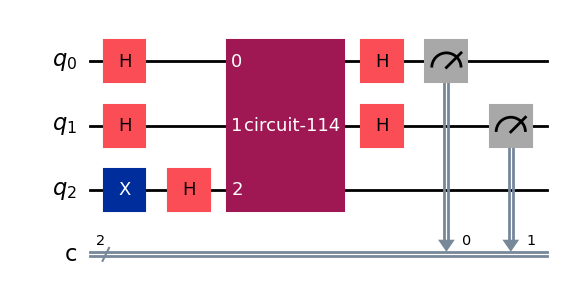

In [28]:
dj_const.draw('mpl')
dj_bal.draw('mpl')


Deutsch–Jozsa algorithm for determining if a function is constant or balanced.

Resources:
- [Quantum Bits: An in-depth exploration [hands-on Qiskit code] (Article — 2)](https://medium.com/@jyotirajnath7/quantum-bits-an-in-depth-exploration-hands-on-qiskit-code-article-2-e7fbda0078c5)
- [A Beginners’ Guide to Qiskit 1.0](https://medium.com/@harini.hapuarachchi/a-beginners-guide-to-qiskit-1-0-c8e3e854d732)